In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from PIL import Image
import timm
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

c:\Users\ruthr\anaconda3\envs\tenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv(r"r:\diabetic retinopathy\diabetes-re\train.csv")
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3662 entries, 0 to 3661
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id_code    3662 non-null   object
 1   diagnosis  3662 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 57.3+ KB
None
         diagnosis
count  3662.000000
mean      1.126980
std       1.298409
min       0.000000
25%       0.000000
50%       1.000000
75%       2.000000
max       4.000000


C:\Users\ruthr\AppData\Local\Temp\ipykernel_10248\3035282709.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=df, palette='viridis')


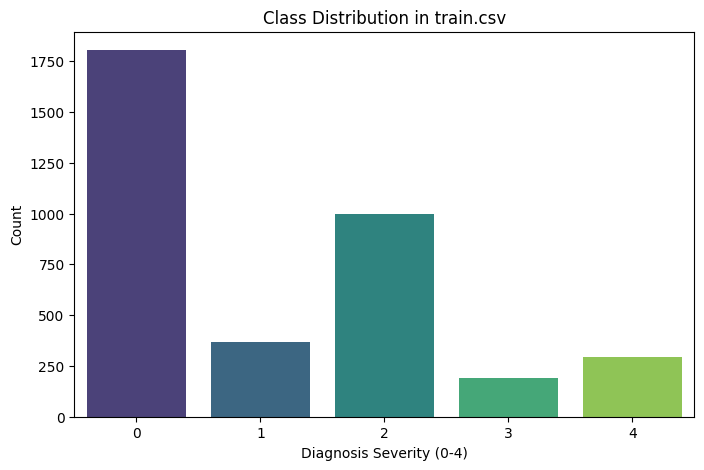

In [3]:
plt.figure(figsize=(8, 5))
sns.countplot(x='diagnosis', data=df, palette='viridis')
plt.title('Class Distribution in train.csv')
plt.xlabel('Diagnosis Severity (0-4)')
plt.ylabel('Count')
plt.show()

In [4]:
DATA_DIR = r"r:\diabetic retinopathy\diabetes-re\colored_images"
outliers = []
for root, dirs, files in os.walk(DATA_DIR):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            path = os.path.join(root, file)
            try:
                with Image.open(path) as img:
                    w, h = img.size
                    mode = img.mode
                    if w < 100 or h < 100 or mode != 'RGB':
                        outliers.append((file, w, h, mode))
            except Exception as e:
                outliers.append((file, 'Corrupt', str(e)))
print(f"Detected outliers/corrupted files: {len(outliers)}")
for o in outliers[:10]:
    print(o)

Detected outliers/corrupted files: 0


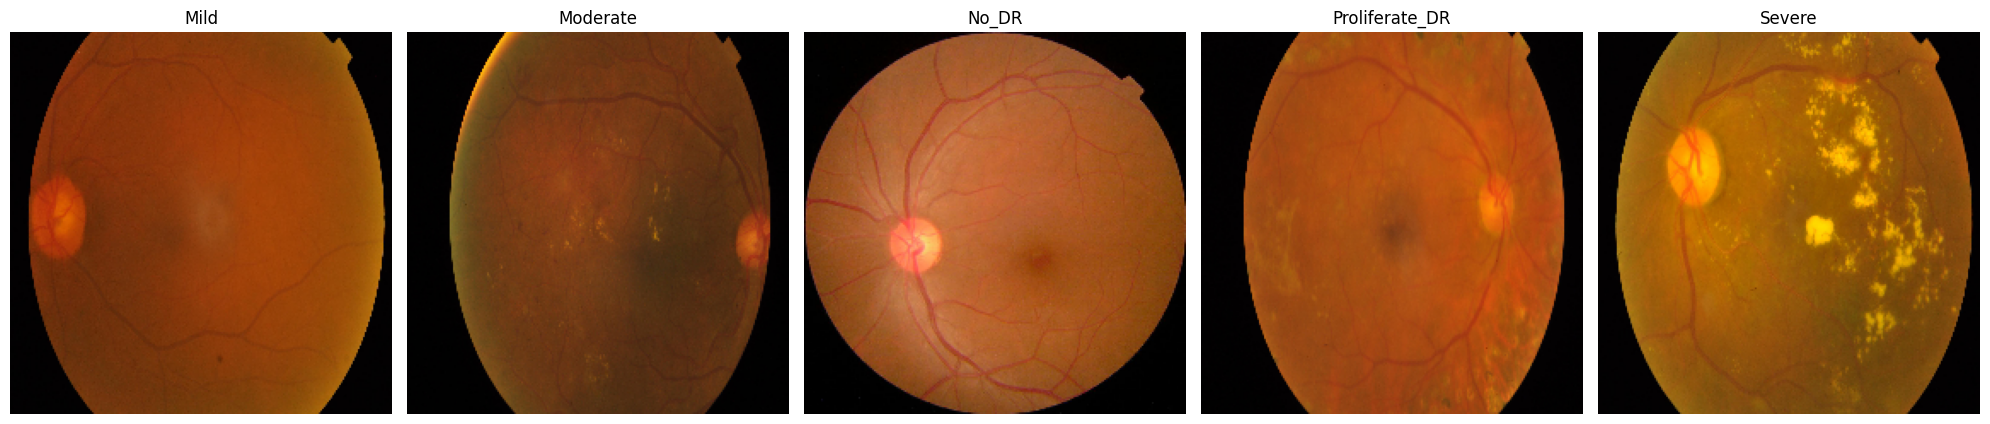

In [5]:
class_folders = [f for f in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, f))]
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for idx, folder in enumerate(class_folders):
    folder_path = os.path.join(DATA_DIR, folder)
    img_name = os.listdir(folder_path)[0]
    img_path = os.path.join(folder_path, img_name)
    img = Image.open(img_path)
    axes[idx].imshow(img)
    axes[idx].set_title(folder)
    axes[idx].axis('off')
plt.tight_layout()
plt.show()

In [6]:
IMAGE_SIZE = 300
BATCH_SIZE = 16
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class BenGrahamPreprocessing(object):
    def __init__(self, size=300, sigmaX=10):
        self.size = size
        self.sigmaX = sigmaX

    def __call__(self, img):
        img = np.array(img)
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        mask = gray > 10
        if mask.any():
            img = img[np.ix_(mask.any(1), mask.any(0))]
        img = cv2.resize(img, (self.size, self.size))
        blurred = cv2.GaussianBlur(img, (0, 0), self.sigmaX)
        enhanced = cv2.addWeighted(img, 4, blurred, -4, 128)
        return Image.fromarray(enhanced)

train_transform = transforms.Compose([
    BenGrahamPreprocessing(size=IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    BenGrahamPreprocessing(size=IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_dataset = ImageFolder(root=DATA_DIR)
generator = torch.Generator().manual_seed(42)
train_data, val_data = random_split(full_dataset, [0.8, 0.2], generator=generator)

class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
    def __len__(self):
        return len(self.subset)

train_dataset = TransformedSubset(train_data, train_transform)
val_dataset = TransformedSubset(val_data, val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

In [7]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=1.5, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        log_p = F.log_softmax(inputs, dim=1)
        ce_loss = F.nll_loss(log_p, targets, weight=self.alpha, reduction='none')
        p = torch.exp(-ce_loss)
        focal_loss = ((1 - p) ** self.gamma) * ce_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

class DiabeticRetinopathyModel(nn.Module):
    def __init__(self, num_classes=5, model_name='efficientnet_b3', pretrained=True):
        super(DiabeticRetinopathyModel, self).__init__()
        self.model = timm.create_model(model_name, pretrained=pretrained)
        in_features = self.model.classifier.in_features
        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(in_features, num_classes)
        )
    def forward(self, x):
        return self.model(x)

model = DiabeticRetinopathyModel(num_classes=5, pretrained=True).to(DEVICE)

beta = 0.999
class_counts = np.array([370, 999, 1805, 295, 193])
effective_num = 1.0 - np.power(beta, class_counts)
weights = (1.0 - beta) / effective_num
weights = weights / np.sum(weights) * 5.0
class_weights = torch.FloatTensor(weights).to(DEVICE)

criterion = FocalLoss(alpha=class_weights, gamma=1.5)

In [8]:
for param in model.model.parameters():
    param.requires_grad = False
for param in model.model.classifier.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, weight_decay=1e-4)

for epoch in range(2):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    pbar = tqdm(train_loader, desc=f"Warmup Epoch {epoch+1}/2")
    for images, labels in pbar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        pbar.set_postfix(loss=loss.item(), acc=100.0 * correct / total)

Warmup Epoch 2/2: 100%|██████████| 184/184 [00:39<00:00,  4.68it/s, acc=60.2, loss=0.239]


In [9]:
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(15):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    pbar = tqdm(train_loader, desc=f"Fine-tune Epoch {epoch+1}/15")
    for images, labels in pbar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        pbar.set_postfix(loss=loss.item(), acc=100.0 * correct / total)
        
    epoch_train_acc = 100.0 * correct / total
    
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
    epoch_val_loss = val_loss / len(val_dataset)
    epoch_val_acc = 100.0 * val_correct / val_total
    scheduler.step()
    
    history['train_loss'].append(running_loss / len(train_dataset))
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)
    
    print(f"Epoch {epoch+1}/15 - Train Acc: {epoch_train_acc:.2f}% | Val Acc: {epoch_val_acc:.2f}% | Val Loss: {epoch_val_loss:.4f}")
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), 'best_diabetic_retinopathy_model.pth')
        print("Checkpoint saved!")

Fine-tune Epoch 1/15: 100%|██████████| 184/184 [01:23<00:00,  2.21it/s, acc=66.7, loss=0.166]


Epoch 1/15 - Train Acc: 66.72% | Val Acc: 65.16% | Val Loss: 0.3215
Checkpoint saved!


Fine-tune Epoch 2/15: 100%|██████████| 184/184 [01:23<00:00,  2.20it/s, acc=66.2, loss=0.141]


Epoch 2/15 - Train Acc: 66.21% | Val Acc: 65.44% | Val Loss: 0.3011
Checkpoint saved!


Fine-tune Epoch 3/15: 100%|██████████| 184/184 [01:23<00:00,  2.20it/s, acc=67.7, loss=0.205]


...

Epoch 13/15 - Train Acc: 72.90% | Val Acc: 70.77% | Val Loss: 0.2532
Checkpoint saved!


Fine-tune Epoch 14/15: 100%|██████████| 184/184 [01:24<00:00,  2.19it/s, acc=72.1, loss=0.37]  


Epoch 14/15 - Train Acc: 72.12% | Val Acc: 71.99% | Val Loss: 0.2589


Fine-tune Epoch 15/15: 100%|██████████| 184/184 [01:24<00:00,  2.19it/s, acc=72.9, loss=0.0814]


Epoch 15/15 - Train Acc: 72.87% | Val Acc: 72.54% | Val Loss: 0.2603


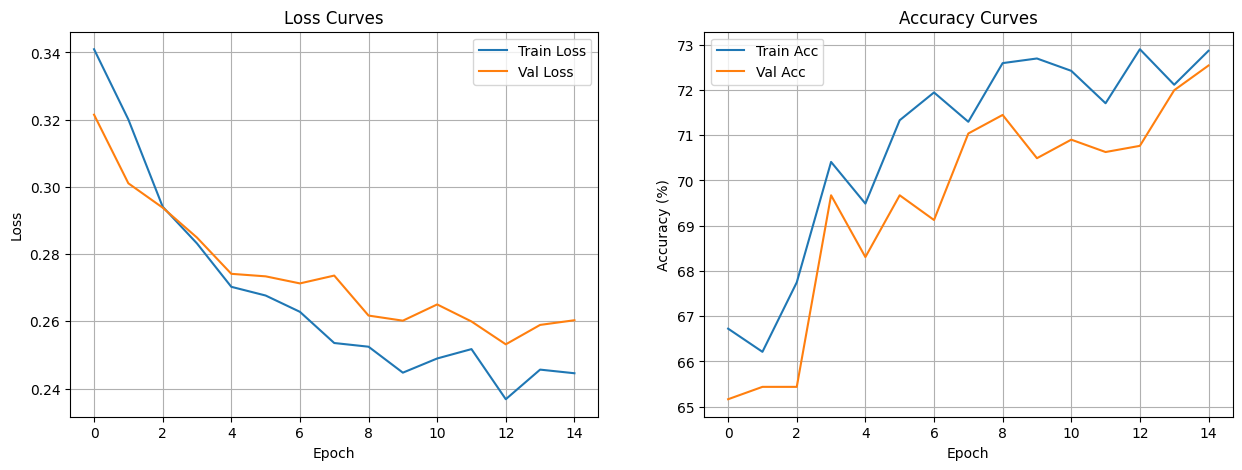

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_title('Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['val_acc'], label='Val Acc')
axes[1].set_title('Accuracy Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True)
plt.show()

                precision    recall  f1-score   support

          Mild       0.34      0.62      0.44        58
      Moderate       0.82      0.40      0.54       211
         No_DR       0.97      0.93      0.95       364
Proliferate_DR       0.34      0.42      0.38        50
        Severe       0.34      0.78      0.47        49

      accuracy                           0.71       732
     macro avg       0.56      0.63      0.56       732
  weighted avg       0.79      0.71      0.72       732



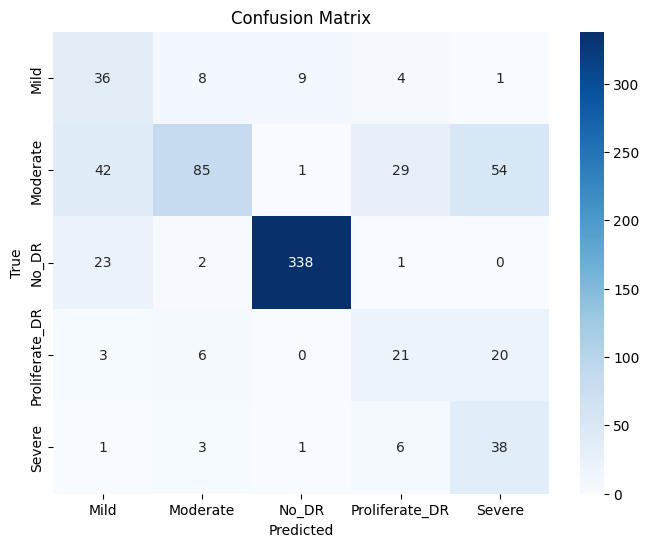

In [11]:
best_model = DiabeticRetinopathyModel(num_classes=5, pretrained=False)
best_model.load_state_dict(torch.load('best_diabetic_retinopathy_model.pth', map_location=DEVICE))
best_model = best_model.to(DEVICE)
best_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(DEVICE)
        outputs = best_model(images)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

class_names = list(full_dataset.class_to_idx.keys())
print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()